# CNN + ViT Invariance — Combined (raw features, per block)

All 6 models on a single axis using raw (flattened) per-block features.
CNNs have 5 blocks; ViTs have 12 blocks. Both are normalised to [0, 1] depth
so they share the same x-axis, with CNN block labels on the bottom and
ViT block labels on the top.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

outdir = 'outputs'

# ── CNN raw per-block ─────────────────────────────────────────────────────────
alexnet_raw = np.load(os.path.join(outdir, 'alexnet_inv_per_conv_raw.npy'),    allow_pickle=True).item()
vgg16_raw   = np.load(os.path.join(outdir, 'vgg16_inv_per_block_raw.npy'),     allow_pickle=True).item()
resnet_raw  = np.load(os.path.join(outdir, 'resnet50_inv_per_block_raw.npy'),  allow_pickle=True).item()

# ── ViT raw per-block ─────────────────────────────────────────────────────────
dinov1_raw  = np.load(os.path.join(outdir, 'dinov1_vit_inv_raw.npy'),  allow_pickle=True).item()
dinov3_raw  = np.load(os.path.join(outdir, 'dinov3_vit_inv_raw.npy'),  allow_pickle=True).item()
sup_raw     = np.load(os.path.join(outdir, 'sup_vit_inv_raw.npy'),     allow_pickle=True).item()

print('CNN  blocks:', len(alexnet_raw['values']), len(vgg16_raw['values']), len(resnet_raw['values']))
print('ViT  blocks:', len(dinov1_raw['values']),  len(dinov3_raw['values']),  len(sup_raw['values']))

CNN  blocks: 5 5 5
ViT  blocks: 12 12 12


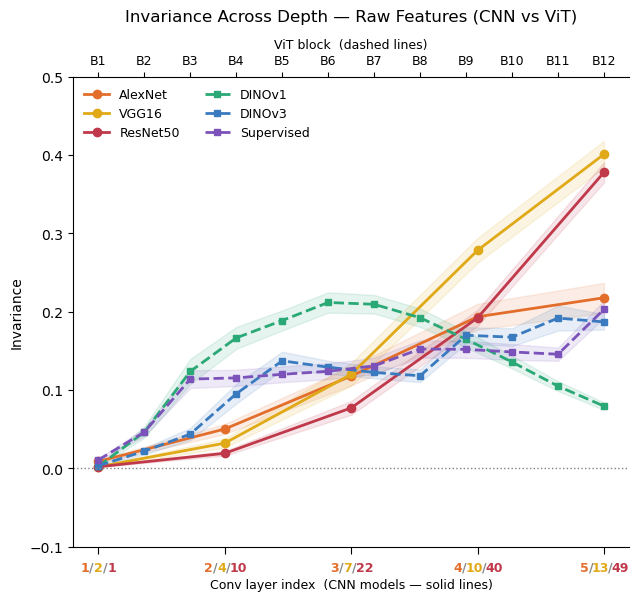

In [3]:
from matplotlib.transforms import blended_transform_factory

def get_mean_sem(d):
    v = d['values']   # (n_layers, 28)
    return v.mean(axis=1), v.std(axis=1) / np.sqrt(v.shape[1])

n_cnn = len(alexnet_raw['values'])   # 5
n_vit = len(dinov1_raw['values'])    # 12

x_cnn = np.linspace(0, 1, n_cnn)
x_vit = np.linspace(0, 1, n_vit)

cnn_models = [
    {'data': alexnet_raw, 'color': '#e36e2b', 'label': 'AlexNet',  'ls': '-'},
    {'data': vgg16_raw,   'color': '#e0a917', 'label': 'VGG16',    'ls': '-'},
    {'data': resnet_raw,  'color': '#c0394b', 'label': 'ResNet50', 'ls': '-'},
]
vit_models = [
    {'data': dinov1_raw, 'color': '#2aa876', 'label': 'DINOv1',     'ls': '--'},
    {'data': dinov3_raw, 'color': '#3a7abf', 'label': 'DINOv3',     'ls': '--'},
    {'data': sup_raw,    'color': '#7b52b9', 'label': 'Supervised', 'ls': '--'},
]

fig, ax = plt.subplots(figsize=(6.5, 6.5))   # square

for m in cnn_models:
    mean, sem = get_mean_sem(m['data'])
    ax.plot(x_cnn, mean, 'o' + m['ls'], color=m['color'], lw=2, ms=6, label=m['label'])
    ax.fill_between(x_cnn, mean - sem, mean + sem, alpha=0.12, color=m['color'])

for m in vit_models:
    mean, sem = get_mean_sem(m['data'])
    ax.plot(x_vit, mean, 's' + m['ls'], color=m['color'], lw=2, ms=5, label=m['label'])
    ax.fill_between(x_vit, mean - sem, mean + sem, alpha=0.12, color=m['color'])

ax.axhline(0, color='gray', lw=1, linestyle=':')
ax.set_ylim(-0.1, 0.5)
ax.set_ylabel('Invariance')
ax.set_xlim(-0.05, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── bottom axis: single-row multicolor labels "AlexNet/VGG16/ResNet" indices ─
# Cumulative conv-layer index at the end of each block per model:
#   AlexNet  (5 conv layers, 1 per block):     1, 2, 3,  4,  5
#   VGG16    (13 conv layers, [2,2,3,3,3]):    2, 4, 7, 10, 13
#   ResNet50 (49 conv layers, [1,9,12,18,9]):  1,10,22, 40, 49
cnn_end_layers = [
    [1,  2,  3,  4,  5],    # AlexNet
    [2,  4,  7, 10, 13],    # VGG16
    [1, 10, 22, 40, 49],    # ResNet50
]

ax.set_xticks(x_cnn)
ax.set_xticklabels([])
ax.tick_params(axis='x', length=5)

trans = blended_transform_factory(ax.transData, ax.transAxes)

char_w    = 0.013
sep_color = '#888888'
y_lbl     = -0.03   # closer to x-axis

for bi, xi in enumerate(x_cnn):
    parts = [str(cnn_end_layers[mi][bi]) for mi in range(3)]
    colors = [m['color'] for m in cnn_models]
    segs = []
    for i, (p, c) in enumerate(zip(parts, colors)):
        if i > 0:
            segs.append(('/', sep_color))
        segs.append((p, c))

    total_w = sum(len(s) * char_w for s, _ in segs)
    cur_x = xi - total_w / 2
    for text, color in segs:
        w = len(text) * char_w
        ax.text(cur_x + w / 2, y_lbl, text, transform=trans,
                ha='center', va='top', fontsize=9,
                color=color, fontweight='semibold')
        cur_x += w

ax.set_xlabel('Conv layer index  (CNN models — solid lines)', fontsize=9, labelpad=14)

# ── top axis: ViT block labels ────────────────────────────────────────────────
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(x_vit)
ax2.set_xticklabels([f'B{i+1}' for i in range(n_vit)], fontsize=9)
ax2.set_xlabel('ViT block  (dashed lines)', fontsize=9)
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

ax.legend(frameon=False, fontsize=9, ncol=2, loc='upper left')
plt.title('Invariance Across Depth — Raw Features (CNN vs ViT)', fontsize=12, pad=40)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('../figures/invariance_combined_raw.png', dpi=300, bbox_inches='tight')
plt.show()